In [2]:
import time

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay

In [4]:
from google.colab import files

uploaded = files.upload()


Saving spambase_csv.csv to spambase_csv (1).csv


In [5]:
data = pd.read_csv("spambase_csv.csv")

data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [6]:
print("Shape :", data.shape)

print("\nColumns")
print(data.columns)

print("\nMissing Values")
print(data.isnull().sum())

data.info()

Shape : (4601, 58)

Columns
Index(['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
       'word_freq_our', 'word_freq_over', 'word_freq_remove',
       'word_freq_internet', 'word_freq_order', 'word_freq_mail',
       'word_freq_receive', 'word_freq_will', 'word_freq_people',
       'word_freq_report', 'word_freq_addresses', 'word_freq_free',
       'word_freq_business', 'word_freq_email', 'word_freq_you',
       'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000',
       'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george',
       'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet',
       'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
       'word_freq_technology', 'word_freq_1999', 'word_freq_parts',
       'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting',
       'word_freq_original', 'word_freq_project', 'word_freq_re',
       'word_freq_edu', 'word_freq_tabl

In [7]:
X = data.drop("class", axis=1)

y = data["class"]

In [8]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

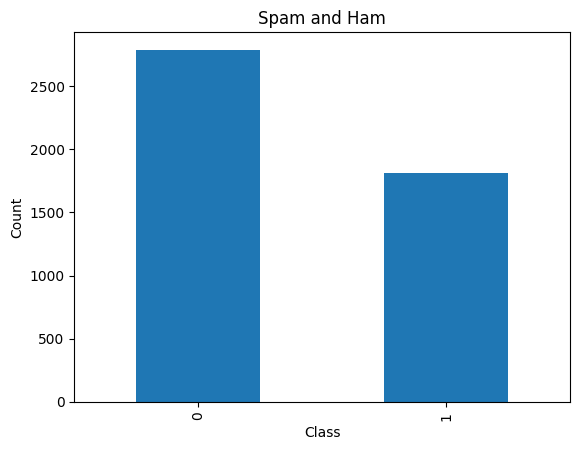

In [9]:
data["class"].value_counts().plot(kind="bar")

plt.title("Spam and Ham")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

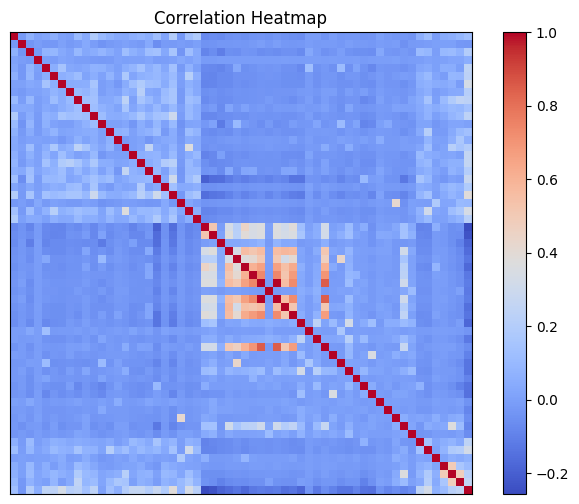

In [10]:
plt.figure(figsize=(8,6))

plt.imshow(data.corr(), cmap="coolwarm")

plt.colorbar()

plt.title("Correlation Heatmap")

plt.xticks([])

plt.yticks([])

plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training :", X_train.shape)

print("Testing :", X_test.shape)

Training : (3680, 57)
Testing : (921, 57)


In [12]:
logistic = LogisticRegression(max_iter=1000)

start = time.time()

logistic.fit(X_train, y_train)

logistic_time = time.time() - start

logistic_pred = logistic.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test, logistic_pred)
precision = precision_score(y_test, logistic_pred)
recall = recall_score(y_test, logistic_pred)
f1 = f1_score(y_test, logistic_pred)

result = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Training Time"],
    "Value": [accuracy, precision, recall, f1, logistic_time]
})

result

,Metric,Value
0,Accuracy,0.919653
1,Precision,0.931694
2,Recall,0.874359
3,F1 Score,0.902116
4,Training Time,0.032336


In [14]:
parameters = {
    "C": [0.1, 1, 10],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters :", grid.best_params_)
print("Best Accuracy :", grid.best_score_)

Best Parameters : {'C': 10, 'solver': 'liblinear'}
Best Accuracy : 0.9258152173913043


In [15]:
linear_model = SVC(kernel="linear")

start = time.time()

linear_model.fit(X_train, y_train)

linear_time = time.time() - start

linear_prediction = linear_model.predict(X_test)

In [16]:
poly_model = SVC(
    kernel="poly",
    degree=3
)

start = time.time()

poly_model.fit(X_train, y_train)

poly_time = time.time() - start

poly_prediction = poly_model.predict(X_test)

In [17]:
rbf_model = SVC(kernel="rbf")

start = time.time()

rbf_model.fit(X_train, y_train)

rbf_time = time.time() - start

rbf_prediction = rbf_model.predict(X_test)

In [18]:
sigmoid_model = SVC(kernel="sigmoid")

start = time.time()

sigmoid_model.fit(X_train, y_train)

sigmoid_time = time.time() - start

sigmoid_prediction = sigmoid_model.predict(X_test)

In [20]:
svm_parameters = {
    "kernel": ["linear", "rbf"],
    "C": [1, 10],
    "gamma": ["scale"]
}

svm_grid = GridSearchCV(
    SVC(),
    svm_parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best Parameters :", svm_grid.best_params_)
print("Best Accuracy :", svm_grid.best_score_)

Best Parameters : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Accuracy : 0.93125


In [28]:
logistic_result = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time"
    ],
    "Value": [
        accuracy_score(y_test, logistic_pred),
        precision_score(y_test, logistic_pred),
        recall_score(y_test, logistic_pred),
        f1_score(y_test, logistic_pred),
        logistic_time
    ]
})

logistic_result

,Metric,Value
0,Accuracy,0.919653
1,Precision,0.931694
2,Recall,0.874359
3,F1 Score,0.902116
4,Training Time,0.032336


In [21]:
svm_result = pd.DataFrame({
    "Kernel": [
        "Linear",
        "Polynomial",
        "RBF",
        "Sigmoid"
    ],
    "Accuracy": [
        accuracy_score(y_test, linear_prediction),
        accuracy_score(y_test, poly_prediction),
        accuracy_score(y_test, rbf_prediction),
        accuracy_score(y_test, sigmoid_prediction)
    ],
    "F1 Score": [
        f1_score(y_test, linear_prediction),
        f1_score(y_test, poly_prediction),
        f1_score(y_test, rbf_prediction),
        f1_score(y_test, sigmoid_prediction)
    ],
    "Training Time": [
        linear_time,
        poly_time,
        rbf_time,
        sigmoid_time
    ]
})

svm_result

,Kernel,Accuracy,F1 Score,Training Time
0,Linear,0.925081,0.909091,0.756380
1,Polynomial,0.764387,0.629060,0.606649
2,RBF,0.934853,0.920635,0.351835
3,Sigmoid,0.889251,0.866492,0.415281


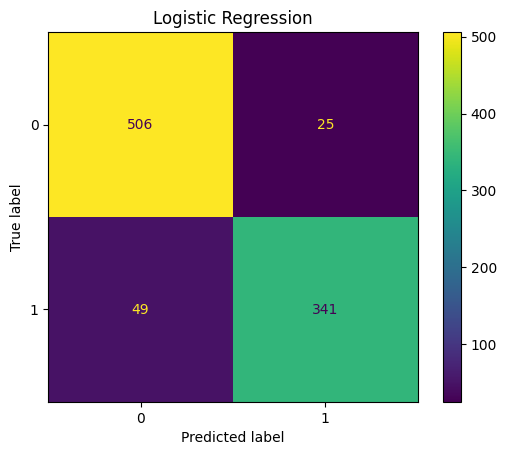

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred
)

plt.title("Logistic Regression")

plt.show()

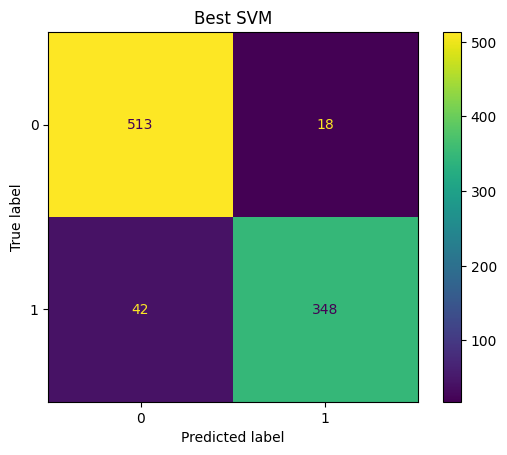

In [23]:
best_model = svm_grid.best_estimator_

best_prediction = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_prediction
)

plt.title("Best SVM")

plt.show()

In [24]:
logistic_cv = cross_val_score(
    logistic,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

svm_cv = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

cv_result = pd.DataFrame({
    "Fold": [
        "Fold 1",
        "Fold 2",
        "Fold 3",
        "Fold 4",
        "Fold 5",
        "Average"
    ],
    "Logistic Regression": [
        logistic_cv[0],
        logistic_cv[1],
        logistic_cv[2],
        logistic_cv[3],
        logistic_cv[4],
        logistic_cv.mean()
    ],
    "SVM": [
        svm_cv[0],
        svm_cv[1],
        svm_cv[2],
        svm_cv[3],
        svm_cv[4],
        svm_cv.mean()
    ]
})

cv_result

,Fold,Logistic Regression,SVM
0,Fold 1,0.918567,0.932682
1,Fold 2,0.928261,0.933696
2,Fold 3,0.929348,0.950000
3,Fold 4,0.940217,0.948913
4,Fold 5,0.840217,0.850000
5,Average,0.911322,0.923058


In [25]:
tuning_result = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Support Vector Machine"
    ],
    "Search Method": [
        "GridSearchCV",
        "GridSearchCV"
    ],
    "Best Parameters": [
        str(grid.best_params_),
        str(svm_grid.best_params_)
    ],
    "Best CV Accuracy": [
        grid.best_score_,
        svm_grid.best_score_
    ]
})

tuning_result

,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,GridSearchCV,"{'C': 10, 'solver': 'liblinear'}",0.925815
1,Support Vector Machine,GridSearchCV,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.931250


In [26]:
comparison = pd.DataFrame({
    "Criterion": [
        "Accuracy",
        "Model Complexity",
        "Training Time",
        "Interpretability"
    ],
    "Logistic Regression": [
        accuracy_score(y_test, logistic_pred),
        "Low",
        logistic_time,
        "High"
    ],
    "SVM": [
        accuracy_score(y_test, best_prediction),
        "High",
        min(linear_time, poly_time, rbf_time, sigmoid_time),
        "Low"
    ]
})

comparison

,Criterion,Logistic Regression,SVM
0,Accuracy,0.919653,0.934853
1,Model Complexity,Low,High
2,Training Time,0.032336,0.351835
3,Interpretability,High,Low


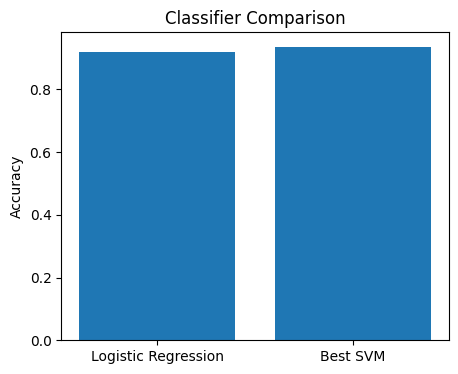

In [27]:
models = ["Logistic Regression", "Best SVM"]

scores = [
    accuracy_score(y_test, logistic_pred),
    accuracy_score(y_test, best_prediction)
]

plt.figure(figsize=(5,4))

plt.bar(models, scores)

plt.ylabel("Accuracy")

plt.title("Classifier Comparison")

plt.show()